# SmartReview AI - Week 2

## 1. Problem Framing

The SmartReview AI system aims to extract meaningful insights from customer reviews and assist users in making informed decisions.

The system is designed to solve the following four key sub-problems:

1. Sentiment Analysis:
   Classify reviews into positive or negative categories based on textual content.

2. Helpfulness Prediction:
   Predict how useful a review will be to other users based on its content and metadata.

3. Fake Review Detection:
   Identify suspicious or low-quality reviews that may not be genuine.

4. Review Summarization:
   Generate concise summaries of long reviews to improve readability and user experience.

## 2. Dataset Loading

In [2]:
# ================================
# DATA LOADING (FINAL STABLE VERSION)
# ================================
import pandas as pd

print("="*60)
print("DATASET LOADING")
print("="*60)

df = pd.read_csv(
    "Reviews.csv",
    engine="python",         # required for broken rows
    encoding="latin-1",
    sep=",",
    quotechar='"',
    escapechar='\\',
    on_bad_lines="skip"      # skip only problematic rows
)

print("\nDataset Loaded Successfully!")
print(f"Total Rows    : {df.shape[0]}")
print(f"Total Columns : {df.shape[1]}")

display(df.head())

DATASET LOADING

Dataset Loaded Successfully!
Total Rows    : 568415
Total Columns : 10


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [3]:
# ================================
# Compare with Original Size
# ================================
original_rows = 568454
loaded_rows = len(df)

print("\n Data Summary:")
print("Original rows:", original_rows)
print("Loaded rows:", loaded_rows)
print("Rows removed:", original_rows - loaded_rows)
print("Data retained (%):", round((loaded_rows / original_rows) * 100, 2))


 Data Summary:
Original rows: 568454
Loaded rows: 568415
Rows removed: 39
Data retained (%): 99.99


In [4]:
df_original = df.copy()

## 3. Data Understanding

In [5]:
import pandas as pd

print("="*60)
print("DATASET OVERVIEW")
print("="*60)

# Shape
rows, cols = df.shape
print(f"\n Total Rows    : {rows}")
print(f"\n Total Columns : {cols}")

print("\n" + "="*60)
print("COLUMN DETAILS")
print("="*60)

# Column info table
column_info = pd.DataFrame({
    "Column Name": df.columns,
    "Data Type": df.dtypes.values,
    "Missing Values": df.isnull().sum().values,
    "Unique Values": df.nunique().values
})

display(column_info)

print("\n" + "="*60)
print("NUMERICAL SUMMARY")
print("="*60)

display(df.describe())

print("\n" + "="*60)
print("RATING DISTRIBUTION")
print("="*60)

display(df['Score'].value_counts().sort_index())

DATASET OVERVIEW

 Total Rows    : 568415

 Total Columns : 10

COLUMN DETAILS


,Column Name,Data Type,Missing Values,Unique Values
0,Id,int64,0,568415
1,ProductId,object,0,74256
2,UserId,object,0,256045
3,ProfileName,object,26,218404
4,HelpfulnessNumerator,int64,0,231
5,HelpfulnessDenominator,int64,0,234
6,Score,int64,0,5
7,Time,int64,0,3168
8,Summary,object,27,295722
9,Text,object,0,393551



NUMERICAL SUMMARY


,Id,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time
count,568415.000000,568415.000000,568415.000000,568415.000000,5.684150e+05
mean,284232.668313,1.743888,2.228872,4.183252,1.296255e+09
std,164098.807297,7.636762,8.290003,1.310401,4.804420e+07
min,1.000000,0.000000,0.000000,1.000000,9.393408e+08
25%,142120.500000,0.000000,0.000000,4.000000,1.271290e+09
50%,284236.000000,0.000000,1.000000,5.000000,1.311120e+09
75%,426345.500000,2.000000,2.000000,5.000000,1.332720e+09
max,568454.000000,866.000000,923.000000,5.000000,1.351210e+09



RATING DISTRIBUTION


,count
Score,
1,52262
2,29760
3,42637
4,80650
5,363106


/tmp/ipykernel_1292/985890946.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Score', data=df, palette='viridis')


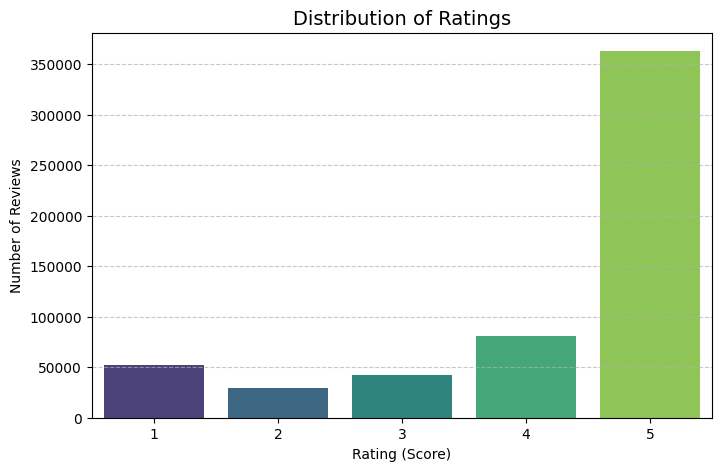

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.countplot(x='Score', data=df, palette='viridis')

plt.title("Distribution of Ratings", fontsize=14)
plt.xlabel("Rating (Score)")
plt.ylabel("Number of Reviews")

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

## 4. Data Cleaning

In [7]:
df = df_original.copy()
print("Reset dataset:", df.shape)

Reset dataset: (568415, 10)


In [8]:
import pandas as pd

print("\n DATA CLEANING")

# Initial shape
print("Initial Shape:", df.shape)

# -----------------------------
# Handle Missing Values
# -----------------------------
df['Text'] = df['Text'].fillna("")
df['Summary'] = df['Summary'].fillna("No Summary")
df['ProfileName'] = df['ProfileName'].fillna("Unknown")

# -----------------------------
# Feature Engineering
# -----------------------------
df['review_length'] = df['Text'].apply(len)
df['helpful_votes'] = df['HelpfulnessNumerator']
df['helpfulness_ratio'] = df['HelpfulnessNumerator'] / (df['HelpfulnessDenominator'] + 1)

print("Features created: review_length, helpful_votes, helpfulness_ratio")

# -----------------------------
# Final Missing Check
# -----------------------------
missing = df.isnull().sum()
missing = missing[missing > 0]

print("\nRemaining Missing Values:")
print(missing if len(missing) > 0 else "No missing values")

# Final shape
print("\nFinal Shape:", df.shape)

# Sample check
print("\nSample Data:")
display(df[['review_length','helpful_votes','helpfulness_ratio']].head())


 DATA CLEANING
Initial Shape: (568415, 10)
Features created: review_length, helpful_votes, helpfulness_ratio

Remaining Missing Values:
No missing values

Final Shape: (568415, 13)

Sample Data:


,review_length,helpful_votes,helpfulness_ratio
0,263,1,0.50
1,190,0,0.00
2,509,1,0.50
3,219,3,0.75
4,140,0,0.00


## 5. Exploratory Data Analysis (EDA)


EXPLORATORY DATA ANALYSIS


/tmp/ipykernel_1292/2529656526.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Score', data=df, palette='viridis')


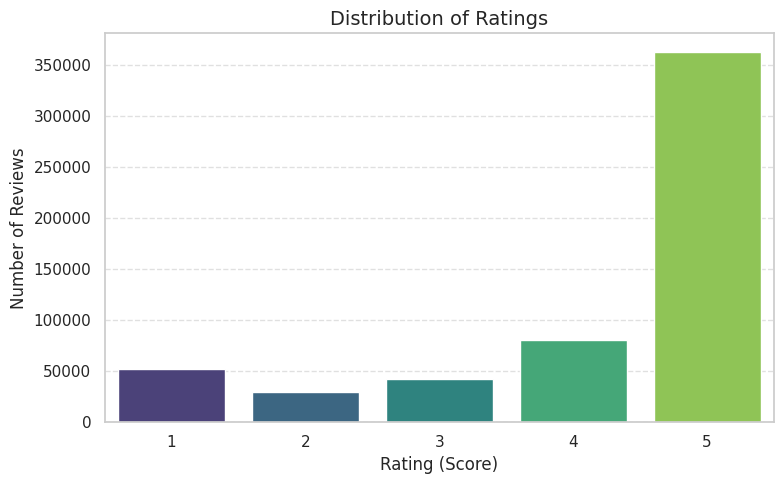

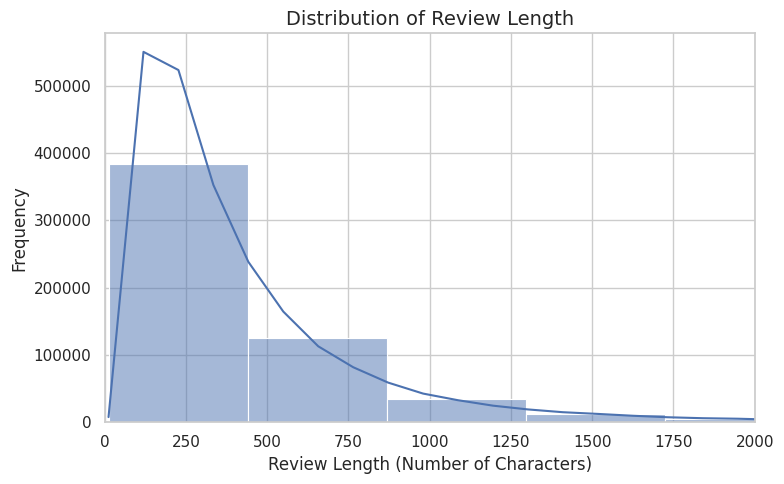

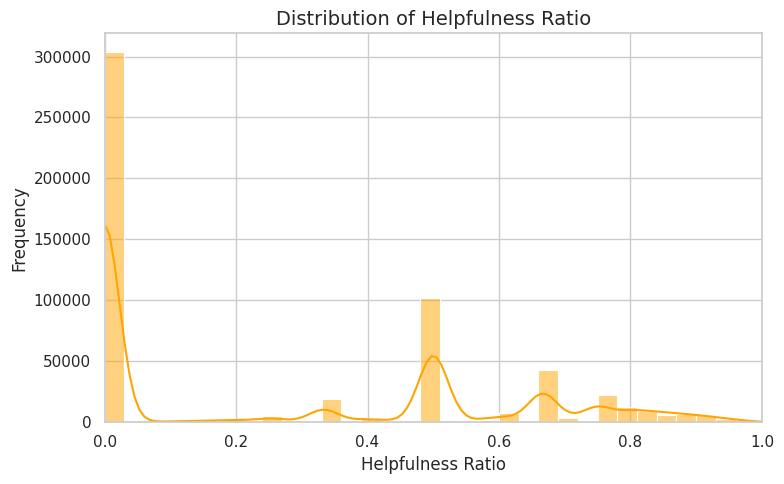

/tmp/ipykernel_1292/2529656526.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Score', y='review_length', data=df,


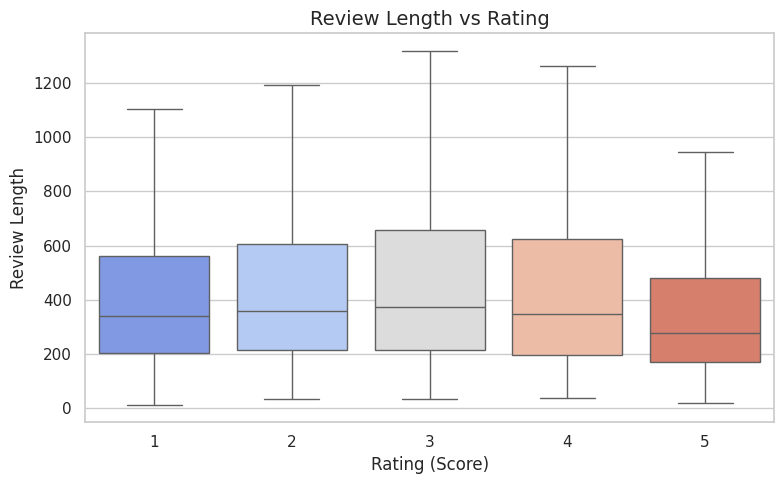

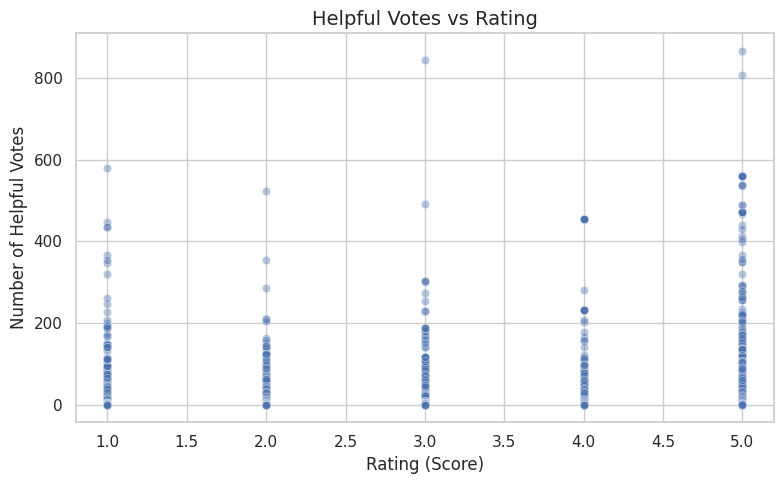

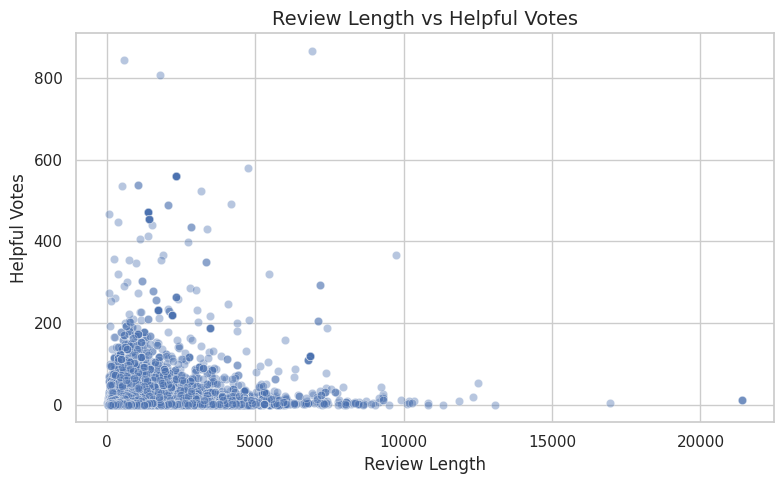

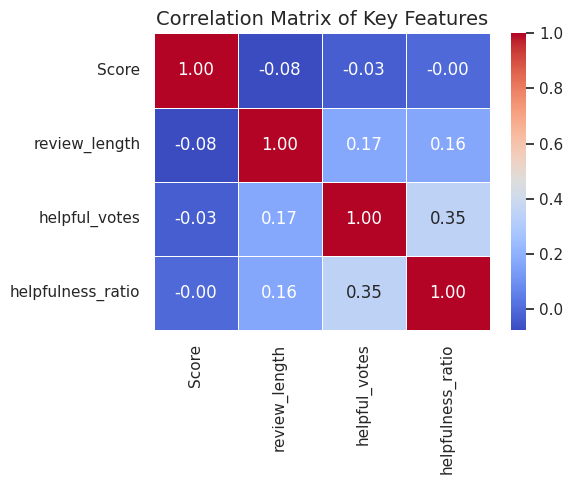

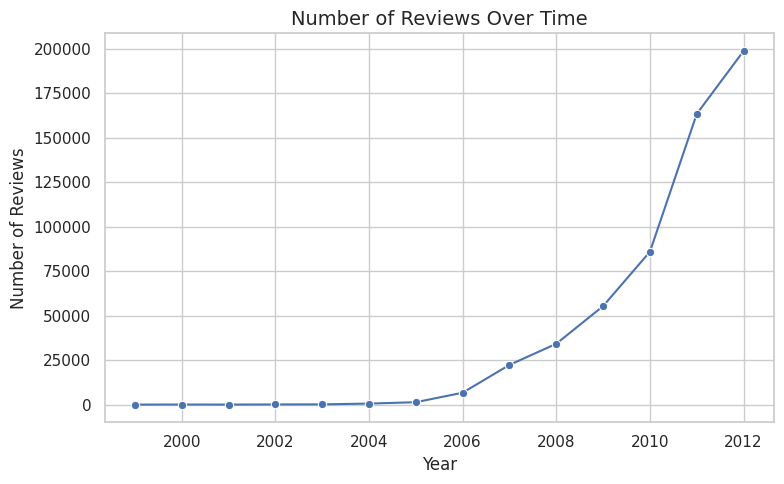

/tmp/ipykernel_1292/2529656526.py:162: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_users.values,


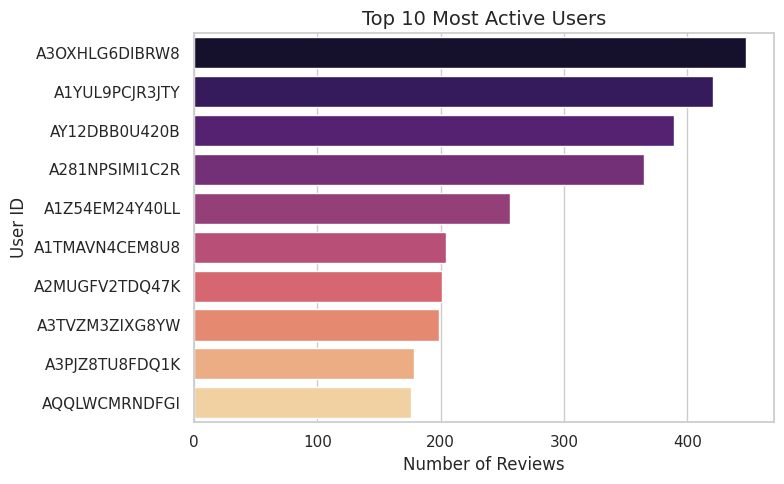

In [9]:
# ============================================================
# EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.titlesize": 14,
    "axes.labelsize": 12
})

print("\n" + "="*60)
print("EXPLORATORY DATA ANALYSIS")
print("="*60)


# ============================================================
# DISTRIBUTION OF RATINGS
# ============================================================
plt.figure()
sns.countplot(x='Score', data=df, palette='viridis')

plt.title("Distribution of Ratings")
plt.xlabel("Rating (Score)")
plt.ylabel("Number of Reviews")
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


# ============================================================
# DISTRIBUTION OF REVIEW LENGTH
# ============================================================
plt.figure()
sns.histplot(df['review_length'], bins=50, kde=True)

plt.xlim(0, 2000)  # Remove extreme outliers for clarity
plt.title("Distribution of Review Length")
plt.xlabel("Review Length (Number of Characters)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


# ============================================================
# DISTRIBUTION OF HELPFULNESS RATIO
# ============================================================
plt.figure()
sns.histplot(df['helpfulness_ratio'], bins=50, kde=True, color='orange')

plt.xlim(0, 1)
plt.title("Distribution of Helpfulness Ratio")
plt.xlabel("Helpfulness Ratio")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


# ============================================================
# REVIEW LENGTH VS RATING
# ============================================================
plt.figure()
sns.boxplot(x='Score', y='review_length', data=df,
            showfliers=False, palette='coolwarm')

plt.title("Review Length vs Rating")
plt.xlabel("Rating (Score)")
plt.ylabel("Review Length")

plt.tight_layout()
plt.show()


# ============================================================
# HELPFUL VOTES VS RATING
# ============================================================
plt.figure()
sns.scatterplot(x='Score', y='helpful_votes',
                data=df, alpha=0.4)

plt.title("Helpful Votes vs Rating")
plt.xlabel("Rating (Score)")
plt.ylabel("Number of Helpful Votes")

plt.tight_layout()
plt.show()


# ============================================================
# REVIEW LENGTH VS HELPFUL VOTES
# ============================================================
plt.figure()
sns.scatterplot(x='review_length', y='helpful_votes',
                data=df, alpha=0.4)

plt.title("Review Length vs Helpful Votes")
plt.xlabel("Review Length")
plt.ylabel("Helpful Votes")

plt.tight_layout()
plt.show()


# ============================================================
# CORRELATION MATRIX
# ============================================================
plt.figure(figsize=(6,5))

corr = df[['Score', 'review_length',
           'helpful_votes', 'helpfulness_ratio']].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5,
    linecolor='white'
)

plt.title("Correlation Matrix of Key Features")

plt.tight_layout()
plt.show()


# ============================================================
# TIME-BASED TREND OF REVIEWS (IMPORTANT)
# ============================================================
df['Time'] = pd.to_datetime(df['Time'], unit='s')
df['Year'] = df['Time'].dt.year

reviews_per_year = df['Year'].value_counts().sort_index()

plt.figure()
sns.lineplot(x=reviews_per_year.index,
             y=reviews_per_year.values,
             marker='o')

plt.title("Number of Reviews Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Reviews")

plt.grid(True)
plt.tight_layout()
plt.show()


# ============================================================
# TOP 10 MOST ACTIVE USERS
# ============================================================
top_users = df['UserId'].value_counts().head(10)

plt.figure(figsize=(8,5))
sns.barplot(x=top_users.values,
            y=top_users.index,
            palette='magma')

plt.title("Top 10 Most Active Users")
plt.xlabel("Number of Reviews")
plt.ylabel("User ID")

plt.tight_layout()
plt.show()

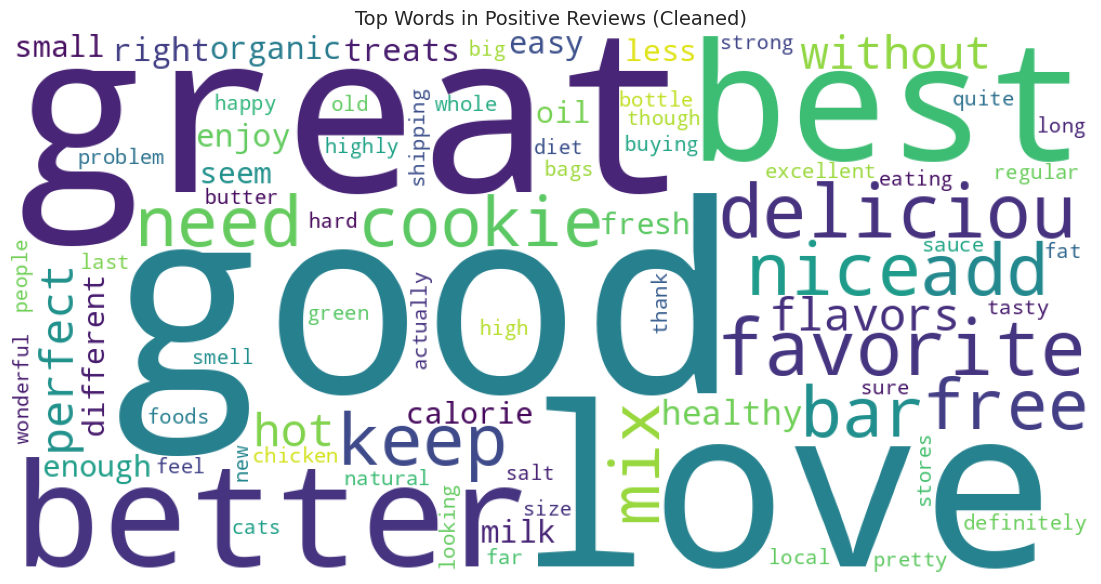

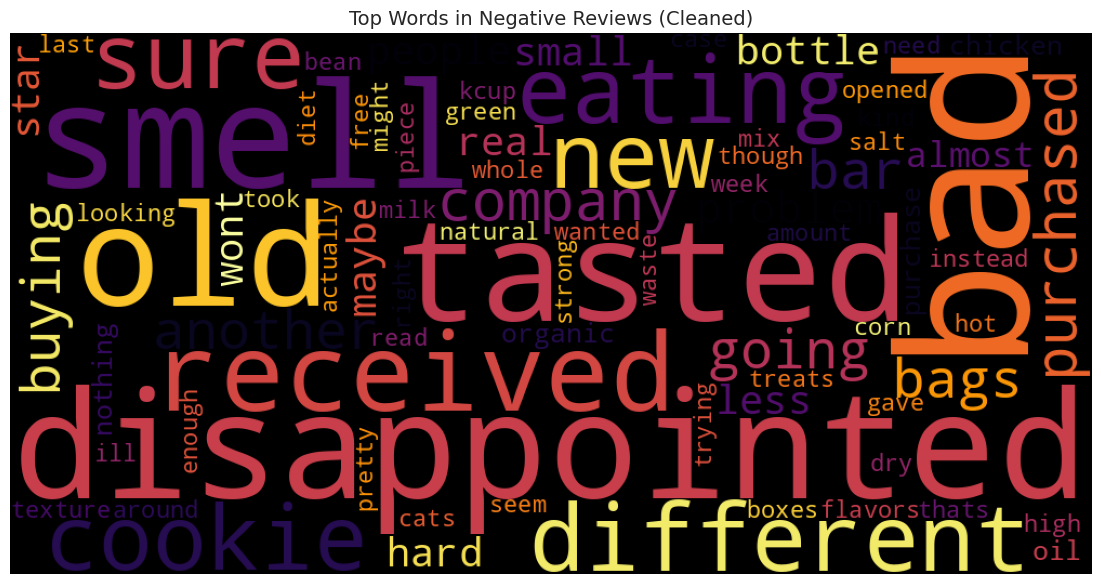

In [10]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
import re

# ================================
# 1. Strong Stopwords
# ================================
stopwords = set(STOPWORDS)

custom_words = [
    # Basic noise
    'br','one','will','use','amazon','product','item',
    'buy','bought','order','ordered','really','get','make','time','try',
    'even','also','still','much','first','well','used','using',
    'found','now','got','way','thing','things','go','see',
    'say','said','came','come','dont','quality','sweet','may',
    'money','look','make','makes','away','put','take','work','pack','package',

    # Neutral frequent words (IMPORTANT)
    'taste','tastes','tried','day','year','find','want','give',

    'ingredient','ingredients','brand','chip','chips',

    # Contractions
    'im','ive','youre','theyre','cant','didnt','doesnt',

    # Domain words
    'coffee','tea','cup','drink','eat','flavor','made',
    'box','bag','water','dog','dogs','cat','store','snack','treat','chocolate',
    'food','sugar','juice','thought',

    # Generic filler
    'review','reviews','product','products','one','two','three','recommend',
    'know','think','little','bit','lot','many','something','anything','never',
    'price','back','stuff','make','makes','every','always','years','month',
]

stopwords.update(custom_words)

# ================================
# 2. Clean Text Function
# ================================
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

df['clean_text'] = df['Text'].astype(str).apply(clean_text)

# ================================
# 3. Remove Positive Words from Negative Reviews
# ================================
positive_words = ['good','great','love','best','better','excellent','nice','favorite']

def remove_positive_words(text):
    words = text.split()
    filtered_words = [w for w in words if w not in positive_words]
    return " ".join(filtered_words)

# ================================
# 4. Prepare Text
# ================================
positive_text = " ".join(df[df['Score'] >= 4]['clean_text'])

negative_df = df[df['Score'] <= 2].copy()
negative_df['clean_text'] = negative_df['clean_text'].apply(remove_positive_words)
negative_text = " ".join(negative_df['clean_text'])

# ================================
# 5. Positive WordCloud
# ================================
plt.figure(figsize=(12,6))

wc_pos = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    stopwords=stopwords,
    colormap='viridis',
    collocations=False,
    max_words=80,
    min_word_length=3
).generate(positive_text)

plt.imshow(wc_pos)
plt.axis('off')
plt.title("Top Words in Positive Reviews (Cleaned)", fontsize=14)
plt.tight_layout()
plt.show()

# ================================
# 6. Negative WordCloud
# ================================
plt.figure(figsize=(12,6))

wc_neg = WordCloud(
    width=1000,
    height=500,
    background_color='black',
    stopwords=stopwords,
    colormap='inferno',
    collocations=False,
    max_words=80,
    min_word_length=3
).generate(negative_text)

plt.imshow(wc_neg)
plt.axis('off')
plt.title("Top Words in Negative Reviews (Cleaned)", fontsize=14)
plt.tight_layout()
plt.show()

Positive reviews focus on quality, taste, and satisfaction.
Negative reviews highlight issues like product quality, packaging, or dissatisfaction.

## 6. Key Insights

In [11]:
# Calculate percentages
total_reviews = len(df)

five_star_count = (df['Score'] == 5).sum()
one_star_count = (df['Score'] == 1).sum()

five_star_pct = (five_star_count / total_reviews) * 100
one_star_pct = (one_star_count / total_reviews) * 100

print("📊 Rating Distribution Analysis:")
print(f"Total Reviews      : {total_reviews}")
print(f"5-Star Reviews     : {five_star_count} ({five_star_pct:.2f}%)")
print(f"1-Star Reviews     : {one_star_count} ({one_star_pct:.2f}%)")

📊 Rating Distribution Analysis:
Total Reviews      : 568415
5-Star Reviews     : 363106 (63.88%)
1-Star Reviews     : 52262 (9.19%)



📊 Relationship Between Review Length and Helpfulness:
Correlation (review_length vs helpful_votes): 0.171


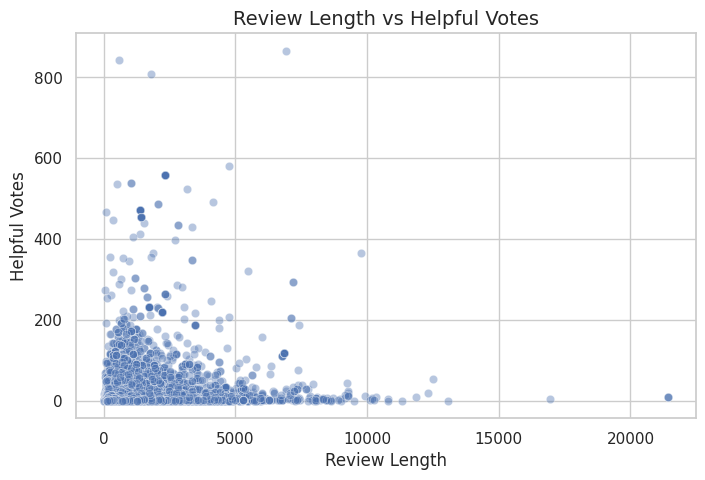

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation value
corr_value = df[['review_length', 'helpful_votes']].corr().iloc[0,1]

print("\n📊 Relationship Between Review Length and Helpfulness:")
print(f"Correlation (review_length vs helpful_votes): {corr_value:.3f}")

# Visualization
plt.figure(figsize=(8,5))
sns.scatterplot(x='review_length', y='helpful_votes', data=df, alpha=0.4)

plt.title("Review Length vs Helpful Votes")
plt.xlabel("Review Length")
plt.ylabel("Helpful Votes")

plt.show()


📊 Trustworthiness vs Rating:
is_trustworthy
False    4.170534
True     4.228533
Name: Score, dtype: float64


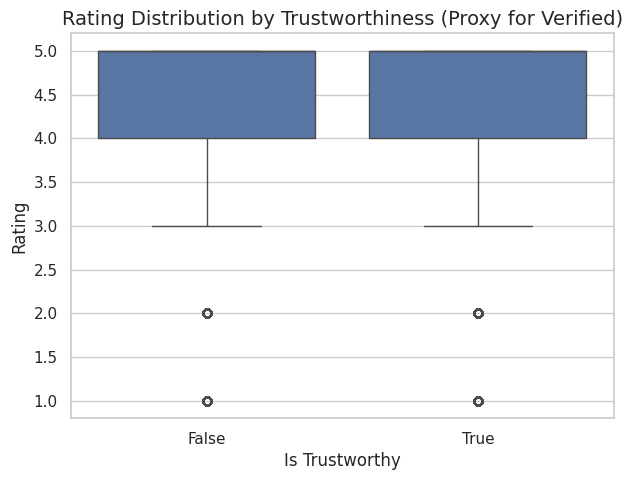

In [13]:
# Create proxy for verified reviews using helpfulness ratio
df['is_trustworthy'] = df['helpfulness_ratio'] > 0.5

# Average rating comparison
trust_rating = df.groupby('is_trustworthy')['Score'].mean()

print("\n📊 Trustworthiness vs Rating:")
print(trust_rating)

# Visualization
plt.figure(figsize=(7,5))
sns.boxplot(x='is_trustworthy', y='Score', data=df)

plt.title("Rating Distribution by Trustworthiness (Proxy for Verified)")
plt.xlabel("Is Trustworthy")
plt.ylabel("Rating")

plt.show()

In [14]:
import pandas as pd
import numpy as np
import re

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

import seaborn as sns
import matplotlib.pyplot as plt

In [15]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [16]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

print("NLP tools ready")

NLP tools ready


In [17]:
def preprocess_text(text):
    text = str(text).lower()

    # Remove HTML
    text = re.sub(r'<.*?>', '', text)

    # Remove punctuation & numbers
    text = re.sub(r'[^a-z\s]', '', text)

    # Tokenize
    tokens = word_tokenize(text)

    # Remove stopwords + lemmatize
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words
    ]

    return " ".join(tokens)

print("Function defined")

Function defined


In [18]:
# ============================================
# APPLY PREPROCESSING
# ============================================

print("Processing text...")

df['processed_text'] = df['Text'].apply(preprocess_text)

print(" Done!")

# Preview
df[['Text', 'processed_text']].head()

Processing text...
 Done!


,Text,processed_text
0,I have bought several of the Vitality canned d...,bought several vitality canned dog food produc...
1,Product arrived labeled as Jumbo Salted Peanut...,product arrived labeled jumbo salted peanutsth...
2,This is a confection that has been around a fe...,confection around century light pillowy citrus...
3,If you are looking for the secret ingredient i...,looking secret ingredient robitussin believe f...
4,Great taffy at a great price. There was a wid...,great taffy great price wide assortment yummy ...


In [19]:
def sentiment(x):
  if x<=2:
    return 0
  elif x==3:
    return 1
  else:
    return 2

df['sentiment'] = df['Score'].apply(sentiment)
print(df["sentiment"].value_counts())

sentiment
2    443756
0     82022
1     42637
Name: count, dtype: int64


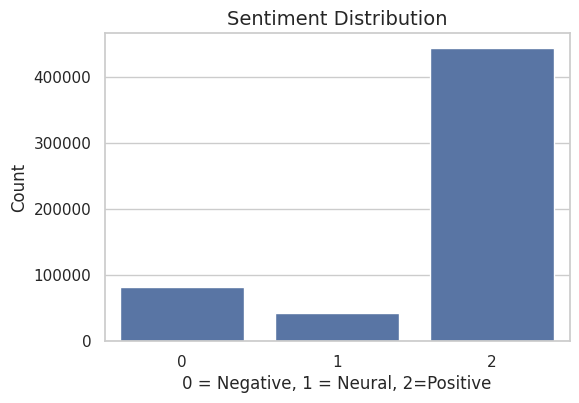

In [20]:
plt.figure(figsize=(6,4))
sns.countplot(x='sentiment', data=df)

plt.title("Sentiment Distribution")
plt.xlabel("0 = Negative, 1 = Neural, 2=Positive")
plt.ylabel("Count")

plt.show()

In [21]:
df['review_length'] = df['processed_text'].apply(lambda x: len(x.split()))

df['HelpfulnessNumerator'] = df['HelpfulnessNumerator'].fillna(0)
df['HelpfulnessDenominator'] = df['HelpfulnessDenominator'].fillna(0)

df['helpful_votes'] = df['HelpfulnessNumerator']

df['helpfulness_ratio'] = df.apply(
    lambda x: x['HelpfulnessNumerator'] / x['HelpfulnessDenominator']
    if x['HelpfulnessDenominator'] > 0 else 0,
    axis=1
)

print("Features created")

df[['processed_text','review_length','helpful_votes','helpfulness_ratio']].head()

Features created


,processed_text,review_length,helpful_votes,helpfulness_ratio
0,bought several vitality canned dog food produc...,23,1,1.0
1,product arrived labeled jumbo salted peanutsth...,18,0,0.0
2,confection around century light pillowy citrus...,40,1,1.0
3,looking secret ingredient robitussin believe f...,18,3,1.0
4,great taffy great price wide assortment yummy ...,13,0,0.0


In [22]:
df.rename(columns={'processed_text': 'cleaned_text'}, inplace=True)

df_final = df[
    ['cleaned_text', 'sentiment', 'review_length', 'helpful_votes', 'helpfulness_ratio']
].copy()

print("✅ Final dataset ready")

df_final.head()

✅ Final dataset ready


,cleaned_text,sentiment,review_length,helpful_votes,helpfulness_ratio
0,bought several vitality canned dog food produc...,2,23,1,1.0
1,product arrived labeled jumbo salted peanutsth...,0,18,0,0.0
2,confection around century light pillowy citrus...,2,40,1,1.0
3,looking secret ingredient robitussin believe f...,0,18,3,1.0
4,great taffy great price wide assortment yummy ...,2,13,0,0.0


In [23]:
print("Shape:", df_final.shape)

print("\nMissing values:")
print(df_final.isnull().sum())

Shape: (568415, 5)

Missing values:
cleaned_text         0
sentiment            0
review_length        0
helpful_votes        0
helpfulness_ratio    0
dtype: int64


In [24]:
df_final.to_csv("cleaned_reviews.csv", index=False)

print("Dataset saved successfully!")

Dataset saved successfully!


In [25]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [26]:
df=df.sample(30000,random_state=42)
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,review_length,helpful_votes,helpfulness_ratio,Year,clean_text,is_trustworthy,cleaned_text,sentiment
62095,62099,B000CQG8K8,A2HOLM5I1ARX9J,"Carol C. ""ccjello""",4,5,5,2009-01-25,most flavorful chai i've found,"Being a fan of the creamy, spicy chai teas one...",94,4,0.8,2009,being a fan of the creamy spicy chai teas one ...,True,fan creamy spicy chai tea one get coffeeshops ...,2
312819,312848,B001NXM3GM,A11OHHI0OTDS1O,"Sarah L. Pia ""Sarahlmnopia""",0,0,5,2009-07-01,THE BEST!,These taste like cheerios! My son loves them! ...,27,0,0.0,2009,these taste like cheerios my son loves them i ...,False,taste like cheerio son love shove little piece...,2
23020,23021,B004ZIER34,AFJFXN42RZ3G2,"R. DelParto ""Rose2""",0,0,4,2011-08-29,Try a cup or more,As an avid coffee drinker but not quite a conn...,60,0,0.0,2011,as an avid coffee drinker but not quite a conn...,False,avid coffee drinker quite connoisseur found da...,2
422405,422440,B000PELR30,A7EK88GF8N40F,Nicole S. Urdang,0,0,5,2009-01-15,Actually cheaper to buy the six boxes of 18 ea...,"I agree this is an exceptional tea, but do the...",20,0,0.0,2009,i agree this is an exceptional tea but do the ...,False,agree exceptional tea math youll see cheaper b...,2
191178,191201,B004OUX2RU,A3M38Y01J19Y55,LChamp,1,1,3,2011-07-10,Tasty but not white,This fondant was really good so you dont have ...,22,1,1.0,2011,this fondant was really good so you dont have ...,False,fondant really good dont go trouble flavoring ...,1


In [27]:
df['avg_rating_per_user']=df.groupby('UserId').Score.transform('mean')
df['avg_rating_per_product']=df.groupby('ProductId').Score.transform('mean')

In [28]:
x=df[['review_length', 'helpfulness_ratio', 'avg_rating_per_user', 'avg_rating_per_product']]
y=df['Score']

In [29]:
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [30]:
model=LogisticRegression()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
accuracy=accuracy_score(y_test,y_pred)
accuracy
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           1       0.78      0.92      0.85       564
           2       0.07      0.01      0.01       310
           3       0.37      0.14      0.21       420
           4       0.03      0.01      0.02       828
           5       0.80      0.98      0.88      3878

    accuracy                           0.73      6000
   macro avg       0.41      0.41      0.39      6000
weighted avg       0.62      0.73      0.67      6000



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [31]:
accuracy

0.7348333333333333

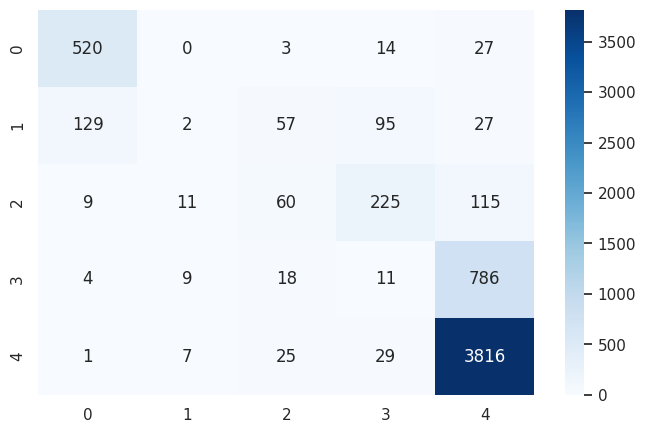

In [32]:
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.show()

In [33]:
tfidf=TfidfVectorizer(max_features=500)
X=tfidf.fit_transform(df['cleaned_text'])

In [34]:
X_combined=hstack([x.values,X])

In [35]:
X_train,X_test,y_train,y_test=train_test_split(X_combined,y,test_size=0.2,random_state=42)

In [36]:
rf=RandomForestClassifier(n_estimators=20,max_depth=10,random_state=42,n_jobs=-1)
rf.fit(X_train,y_train)
rf_y_pred=rf.predict(X_test)
rf_accuracy=accuracy_score(y_test,rf_y_pred)
rf_accuracy

0.7121666666666666

In [37]:
print(classification_report(y_test,rf_y_pred))

              precision    recall  f1-score   support

           1       0.96      0.35      0.52       564
           2       1.00      0.00      0.01       310
           3       0.75      0.01      0.01       420
           4       0.63      0.24      0.34       828
           5       0.71      1.00      0.83      3878

    accuracy                           0.71      6000
   macro avg       0.81      0.32      0.34      6000
weighted avg       0.74      0.71      0.63      6000



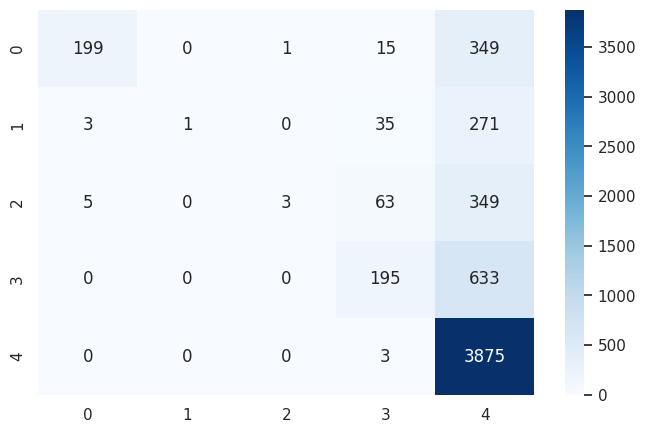

In [38]:
rf_cm=confusion_matrix(y_test,rf_y_pred)
sns.heatmap(rf_cm,annot=True,fmt='d',cmap='Blues')
plt.show()

In [39]:
features = x.columns.tolist() + tfidf.get_feature_names_out().tolist()
important_featues = pd.DataFrame({
    'Feature': features,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False).head(15)

In [40]:
important_featues

,Feature,Importance
2,avg_rating_per_user,0.446435
3,avg_rating_per_product,0.182184
273,love,0.025908
421,star,0.015953
1,helpfulness_ratio,0.013813
292,money,0.010921
495,would,0.010536
35,bad,0.009875
225,however,0.009697
0,review_length,0.008451


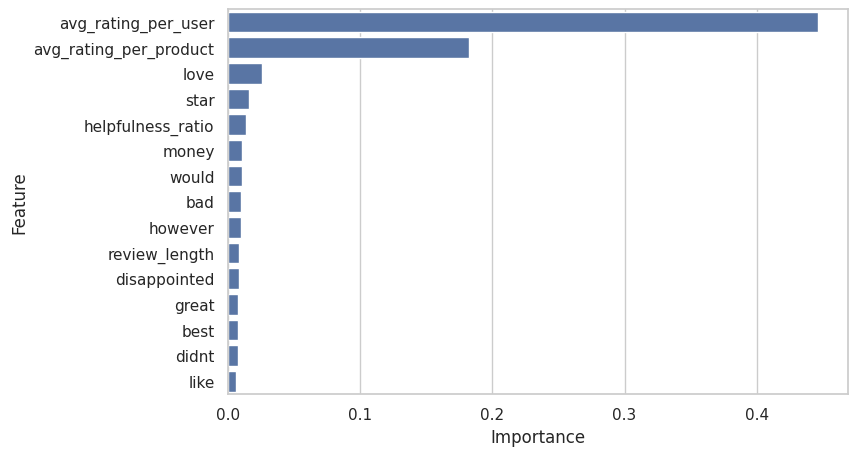

In [41]:
sns.barplot(data=important_featues, x='Importance', y='Feature')
plt.show()

In [42]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt
import seaborn as sns

In [43]:
df['rating_deviation']=abs(df['Score'] - df['avg_rating_per_product'])

In [44]:
user_df=df.groupby('UserId').mean(numeric_only=True)
user_df=user_df.reset_index()

In [45]:
user_df= user_df[['UserId','Score','review_length','helpfulness_ratio']]
user_df

,UserId,Score,review_length,helpfulness_ratio
0,#oc-R109MU5OBBZ59U,5.0,11.0,0.000000
1,#oc-R10UA029WVWIUI,1.0,27.0,0.000000
2,#oc-R11DNU2NBKQ23Z,1.0,15.0,0.000000
3,#oc-R155JB2SA58E17,5.0,36.0,0.000000
4,#oc-R17KN3F3UGQSU0,5.0,42.0,0.333333
...,...,...,...,...
25732,AZYMD9P9F9UZ6,4.5,22.5,0.000000
25733,AZYXC63SS008M,5.0,12.0,0.000000
25734,AZZFJQFHITBZ5,5.0,54.0,1.000000
25735,AZZHZZMH3U1VB,5.0,25.0,0.000000


In [46]:
review_count=df.groupby('UserId').size().reset_index(name='total_reviews_written')
user_df=user_df.merge(review_count,on='UserId')
user_df

,UserId,Score,review_length,helpfulness_ratio,total_reviews_written
0,#oc-R109MU5OBBZ59U,5.0,11.0,0.000000,1
1,#oc-R10UA029WVWIUI,1.0,27.0,0.000000,1
2,#oc-R11DNU2NBKQ23Z,1.0,15.0,0.000000,1
3,#oc-R155JB2SA58E17,5.0,36.0,0.000000,1
4,#oc-R17KN3F3UGQSU0,5.0,42.0,0.333333,1
...,...,...,...,...,...
25732,AZYMD9P9F9UZ6,4.5,22.5,0.000000,2
25733,AZYXC63SS008M,5.0,12.0,0.000000,1
25734,AZZFJQFHITBZ5,5.0,54.0,1.000000,1
25735,AZZHZZMH3U1VB,5.0,25.0,0.000000,1


In [47]:
x=user_df[['Score','review_length','helpfulness_ratio','total_reviews_written']]

In [48]:
scalar=StandardScaler()
x_scaled=scalar.fit_transform(x)

In [49]:
inertia = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(x_scaled)
    inertia.append(kmeans.inertia_)

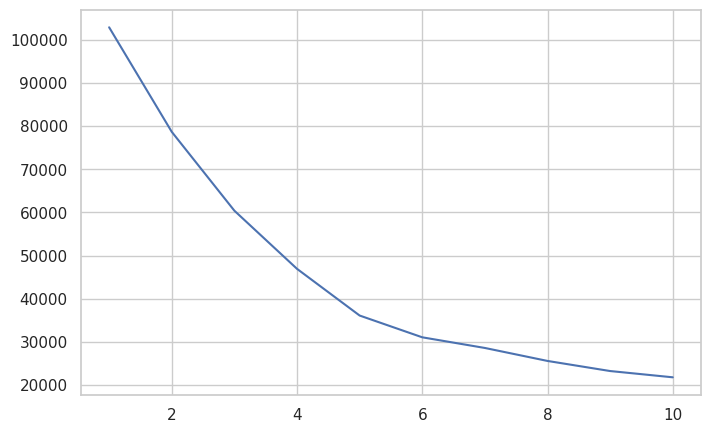

In [50]:
plt.plot(range(1,11),inertia)
plt.show()

In [51]:
kmeans = KMeans(n_clusters=4,random_state=42)
user_df['cluster']=kmeans.fit_predict(x_scaled)
user_df

,UserId,Score,review_length,helpfulness_ratio,total_reviews_written,cluster
0,#oc-R109MU5OBBZ59U,5.0,11.0,0.000000,1,1
1,#oc-R10UA029WVWIUI,1.0,27.0,0.000000,1,2
2,#oc-R11DNU2NBKQ23Z,1.0,15.0,0.000000,1,2
3,#oc-R155JB2SA58E17,5.0,36.0,0.000000,1,1
4,#oc-R17KN3F3UGQSU0,5.0,42.0,0.333333,1,1
...,...,...,...,...,...,...
25732,AZYMD9P9F9UZ6,4.5,22.5,0.000000,2,1
25733,AZYXC63SS008M,5.0,12.0,0.000000,1,1
25734,AZZFJQFHITBZ5,5.0,54.0,1.000000,1,3
25735,AZZHZZMH3U1VB,5.0,25.0,0.000000,1,1


In [75]:
user_df.groupby('cluster').mean(numeric_only=True)

,Score,review_length,helpfulness_ratio,total_reviews_written,pca1,pca2
cluster,,,,,,
0,4.141635,118.076309,0.491294,2.511688,2.630723,-0.084734
1,4.712206,28.656446,0.006016,1.076741,-0.756986,-0.157320
2,1.556934,39.407662,0.388799,1.075393,0.475928,-1.685660
3,4.745025,34.826100,0.933089,1.086338,0.304444,1.009220


In [76]:
cluster_names = {
    0: 'Power Reviewers',
    1: 'Casual Reviewers',
    2: 'Dissatisfied Users',
    3: 'Superfans'
}
user_df['cluster_name']=user_df['cluster'].map(cluster_names)

In [77]:
pca=PCA(n_components=2)
pca_data=pca.fit_transform(x_scaled)

In [78]:
user_df['pca1']=pca_data[:,0]
user_df['pca2']=pca_data[:,1]

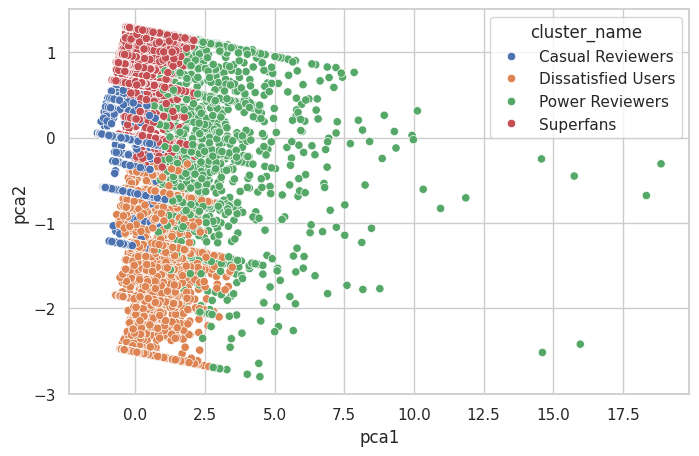

In [79]:
sns.scatterplot(x='pca1',y='pca2', hue='cluster_name',data=user_df)
plt.show()

In [80]:
X_anomaly = df[['review_length','helpfulness_ratio','rating_deviation']]

In [81]:
Scalar=StandardScaler()
X_anomaly_scaled=Scalar.fit_transform(X_anomaly)

In [82]:
model= IsolationForest(contamination=0.05,random_state=42)
df['anomaly_flag']=model.fit_predict(X_anomaly_scaled)

In [83]:
df[df['anomaly_flag'] == -1][['UserId', 'anomaly_flag']]

,UserId,anomaly_flag
381450,A1ZRX0LC6GH6XQ,-1
119939,A393BF47MUH4XC,-1
336213,A2CV6KXDKFYIN1,-1
342362,A3OGYXV9S7MJHM,-1
348697,AIJPCOCLGP2MX,-1
...,...,...
70493,A21Z0377YERLCH,-1
504556,ATJN4KEHJBOC8,-1
527083,A31VASSS5HXPHX,-1
192682,A2KVJ39619SAWP,-1


In [84]:
df['anomaly_label']=df['anomaly_flag'].apply(lambda x: 'anomalies' if x==-1 else 'normal')

In [85]:
pca2=PCA(n_components=2)
anomaly_data=pca2.fit_transform(X_anomaly_scaled)

In [86]:
df['x']=anomaly_data[:,0]
df['y']=anomaly_data[:,1]

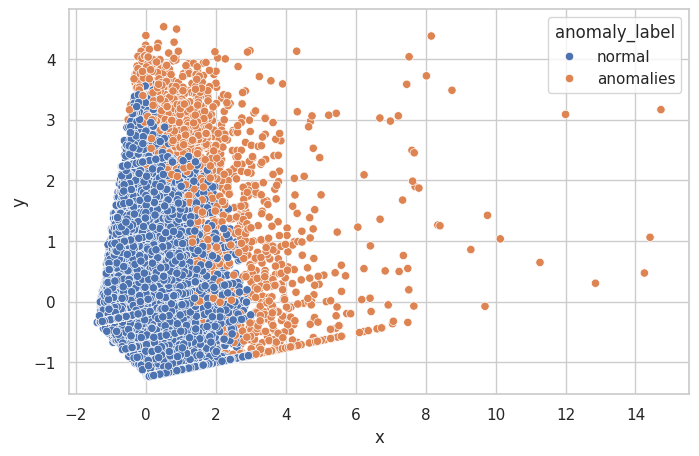

In [87]:
sns.scatterplot(x='x',y='y',hue='anomaly_label',data=df)
plt.show()